# C.2.X. Swaptions

## Module: Options

### DRW New-Hire Learning Program

#### Summer 2023

Questions?
* Contact: Mark Hendricks
* hendricks@uchicago.edu

# Swap

We can decompose swaps into a fixed and floating rate bonds, as seen before.

Still, it is useful to demonstrate that the methods we are using can price any interest-rate derivative--not just options.

Furthermore, having the tree of swap value swill be useful for **swaptions**.

Consider the following parameters:
* swap rate $K=.05$
* maturity $T=5$
* semiannual compounding and frequency

Note that the swap is like the caps and floors in that the payments are based on the previous period's interest rate.

That is, the payoff at time period $i$ is
$$C_{i+1} = N\Delta_t(r_{n,i}-K)$$
where 
* $C_{i+1}$ is the cashflow at period $i+1$ 
* $r_{n,i}$ is the n-frequency compounded rate at period $i$.
* $K$ is the swap rate

In [16]:
STRIKE = .05
N = 100
T=5

tsteps = int(T/dt)

In [17]:
payoff = lambda r: N * dt * (r-STRIKE)

cftree = payoff(refratetree.iloc[:tsteps,:tsteps])
format_bintree(cftree)

time,0.00,0.50,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50
state,,,,,,,,,,
0,-1.63,-1.04,-0.09,0.83,2.12,3.23,4.12,5.07,6.58,8.88
1,,-1.42,-0.72,-0.05,0.89,1.70,2.35,3.04,4.13,5.79
2,,,-1.19,-0.70,-0.00,0.59,1.06,1.56,2.36,3.56
3,,,,-1.17,-0.66,-0.23,0.12,0.49,1.06,1.94
4,,,,,-1.15,-0.83,-0.57,-0.30,0.12,0.76
5,,,,,,-1.27,-1.08,-0.88,-0.57,-0.10
6,,,,,,,-1.45,-1.31,-1.08,-0.73
7,,,,,,,,-1.62,-1.45,-1.20
8,,,,,,,,,-1.73,-1.54


In [18]:
swaptree = bintree_pricing(payoff=payoff, ratetree=ratetree.iloc[:tsteps,:tsteps], undertree= refratetree.iloc[:tsteps,:tsteps], cftree=cftree, timing='deferred')
format_bintree(swaptree)

time,0.00,0.50,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50
state,,,,,,,,,,
0,-2.31,2.23,6.40,9.84,12.56,14.14,14.63,14.05,12.14,7.97
1,,-3.63,0.19,3.44,6.12,7.89,8.80,8.89,7.95,5.35
2,,,-4.69,-1.60,1.04,2.97,4.24,4.87,4.73,3.35
3,,,,-5.52,-2.91,-0.84,0.71,1.79,2.28,1.86
4,,,,,-5.93,-3.76,-1.98,-0.56,0.43,0.74
5,,,,,,-5.97,-4.01,-2.33,-0.96,-0.10
6,,,,,,,-5.54,-3.65,-2.00,-0.72
7,,,,,,,,-4.64,-2.78,-1.18
8,,,,,,,,,-3.35,-1.53


The swap has negative value today.
* It had value of zero at initialization.
* So in this example, the rates have gone lower than the swap rate in the contract, $K$, giving value to the swap receiver.
* We are valuing for the swap payer, so the valuation is negative.

# Swaptions

A **receiver swaption** is 
* a contract today, (with a price paid today)
* for the option, not obligation,
* to enter into a swap **receiving** the swap rate, (set today, like a strike,)
* from $T_1$ to $T_2$.

Thus, the **receiver swaption** is like a **put** on a swap.

A **payer swaption** is the same thing, but the option is to enter into the swap, **paying** the swap rate (strike). Thus, it is like the **call** on a swap.

Of course, being short the **receiver** swaption is not the same thing as being long the **payer** swaption.

### Timing

Note that we have three dates to consider: 
* the option expiration
* the swap start date
* the swap end date

A plain swaption sets the swap to start at the time the option expires.

Thus, a 2\% 1Y$\rightarrow$10Y denotes
* 2\% strike
* swaption with expiration of 1 year
* for a swap starting in 1 year and ending 10 years thereafter (in 11 years)

## Midcurve Swaptions

Suppose that the date of (underlying) swap beginning is **after** the swaption expires. 

This is a **midcurve** swaption.

Could have a 6m$\rightarrow$1Y$\rightarrow$5Y midcurve swaption:
* expires in 6 months
* underlying swap starts one year after that expiration (in 1.5 years from today)
* swap runs for 5 years, (until 6.5 years from today.)

In [19]:
T = 2
tsteps = int(T/dt)+1

payoff = lambda v: np.maximum(v,0)

swaptreeT = swaptree.iloc[:tsteps,:tsteps]

swaption_tree = bintree_pricing(payoff=payoff,  ratetree=ratetree.iloc[:tsteps,:tsteps], undertree= swaptreeT)
format_bintree(swaption_tree)

time,0.00,0.50,1.00,1.50,2.00
state,,,,,
0,2.52,3.98,6.12,9.04,12.56
1,,1.10,1.97,3.49,6.12
2,,,0.25,0.51,1.04
3,,,,0.00,0.00
4,,,,,0.00


### American Swaption

In [20]:
swaption_tree_Amer = bintree_pricing(payoff=payoff,  ratetree=ratetree.iloc[:tsteps,:tsteps], undertree= swaptreeT,style='american')
format_bintree(swaption_tree_Amer)

time,0.00,0.50,1.00,1.50,2.00
state,,,,,
0,2.61,4.18,6.51,9.84,12.56
1,,1.10,1.97,3.49,6.12
2,,,0.25,0.51,1.04
3,,,,0.00,0.00
4,,,,,0.00


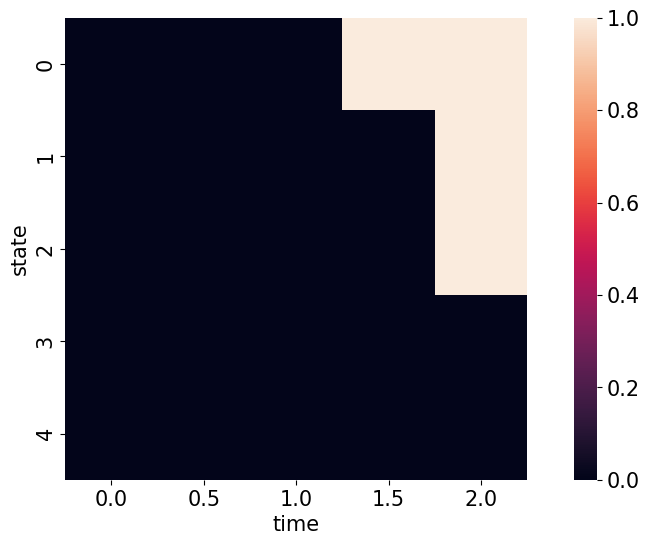

In [21]:
sns.heatmap(exercise_decisions(payoff,undertree=swaptreeT, derivtree=swaption_tree_Amer),square=True);

***

# Swaptions and forward volatilites

Determining forward volatilities is a key part of working with **swaptions**, a massive (in some respects, the largest,) OTC options.

Swaptions are different from caps/floors
* A swaption is a single option on a stream of payments.
* A cap/floor is a stream of options on single payments.

But both can be seen as options on forwards.
* Recall that swaps are portfolios of forward rate agreements.

Accordingly, the **forward volatilities** between caps/floors and swaptions lead to no-arbitrage relationships.

Forward Volatility Agreements (FVAs) are trading implied vol on these forward productions.

### Volatility of the Forward Measure

Consider using Black's model and forward-measure pricing to...
* extract the forward measure (similar to the risk neutral measure) from caps
* apply the measure to swaptions

We can extract what we need from caps with the...
* quoted cap prices 
* forward rates
* discount factors

With the **forward volatilities**...
* convert them to forward-measure volatility
* price swaptions (or anything else depending on these rates) using
    - Black's model
    - monte carlo simulation